# January 24, 2026 Retinanalysis Update Demo: StimGroups, ResponseGroups, and Other Misc Changes

In [1]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# Sample Data to use for examples:
exp_name = '20251112C'
protocol = 'presentmatfiles'
exp_search = ra.get_datasets_from_protocol_names(protocol)
ls_datafiles = exp_search.query('exp_name == @exp_name')['datafile_name'].values
sample_datafile = ls_datafiles[0]

[2026-01-24 14:57:50,059][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306



Found 1 protocols matching "presentmatfiles":
['edu.washington.riekelab.protocols.PresentMatFiles']

Found 20 experiments, 113 epoch blocks.



## Changes to Response Block, Analysis Chunk, and MEA Pipeline

Changes to `MEAResponseBlock`:
- Response block now has a property `self.d_EIs` that is a dictionary containing all of the electrical images for all of the cells in the block. Any cell ids that lack an electrical image are removed from the ResponseBlock and a warning in printed telling you which IDs have been removed.
    - Note: this dictionary is only created if 'include_ei' param is set to 'True' (the default behavior) when initializing the ResponseBlock.
- Response block now has a method `get_cell_types()` which takes optional arguments `noise_chunk` and `typing_file`.
    - This method adds `noise_id` and `cell_type` columns to the Response Block's main dataframe `df_spike_times`, just like initializing a pipeline does.
    - If no `noise_chunk` or `typing_file` are given, the nearest noise chunk to the datafile is used, and the 0th typing file from the list of available files in that noise chunk is used.


Changes to `AnalysisChunk`:
- Analysis chunk now has three new properties:
    - `self.d_EIs`: contains dictionary of EIs for all cells in the analysis chunk. Cell ids for which there are not EIs are removed and a warning is pritned telling you which IDs have been removed. Again, 'include_ei' must be True (default behavior), to generate this dictionary.
    - `self.d_timecourses`: a nested dictionary that contains the red, green, and blue timecourses for each cell. The outer dictionary uses cell_id as key and dict() as value, and the inner dict uses the keys 'red', 'green', and 'blue'.
    - `self.d_ISIs`: a dictionary of ISIs for each cell, as computed by the vcd method `get_acf_numpairs_for_cell()`. We may eventually replace this with a manual computation...

Changes to `MEAPipeline`:
- `pipeline.stim_block` has been replaced by `pipeline.stim`... if someone calls `pipeline.stim_block` it will still work, but will print a warning telling them that this property has been deprecated
- `pipeline.response_block` has been replaced by `pipeline.resp`... if someone calls `pipeline.response_block` it will still work, but will print a warning telling them that this property has been deprecated

In [ ]:
# Initialize response_block
response_block = ra.MEAResponseBlock(exp_name, sample_datafile, b_load_fd = True, verbose=False)

# Response block now has d_EI param:
EI_dict = response_block.d_EIs

# Response block can now have cell type data added to its df_spike_times dataframe:
print('df_spike_times before adding cell types:...')
display(response_block.df_spike_times.head(2))
response_block.add_cell_types(noise_chunk = 'chunk2', typing_file = 'dragos_kilosort2.5.classification.txt')
print('\n')
print('df_spike_times after adding cell types')
display(response_block.df_spike_times.head(2))


df_spike_times before adding cell types:...


,cell_id,spike_times
0,1,"[[86.0, 140.4, 206.9, 240.85000000000002, 264...."
1,3,"[[224.35, 1086.6499999999999, 1096.95, 1103.9,..."




df_spike_times after adding cell types


,cell_id,spike_times,noise_id,cell_type
0,1,"[[86.0, 140.4, 206.9, 240.85000000000002, 264....",1,OnP
1,3,"[[224.35, 1086.6499999999999, 1096.95, 1103.9,...",0,Ummatched


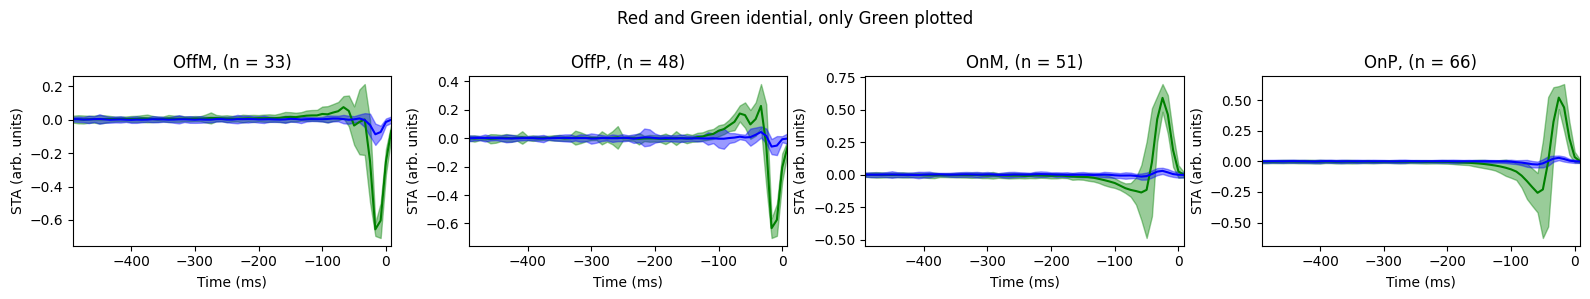

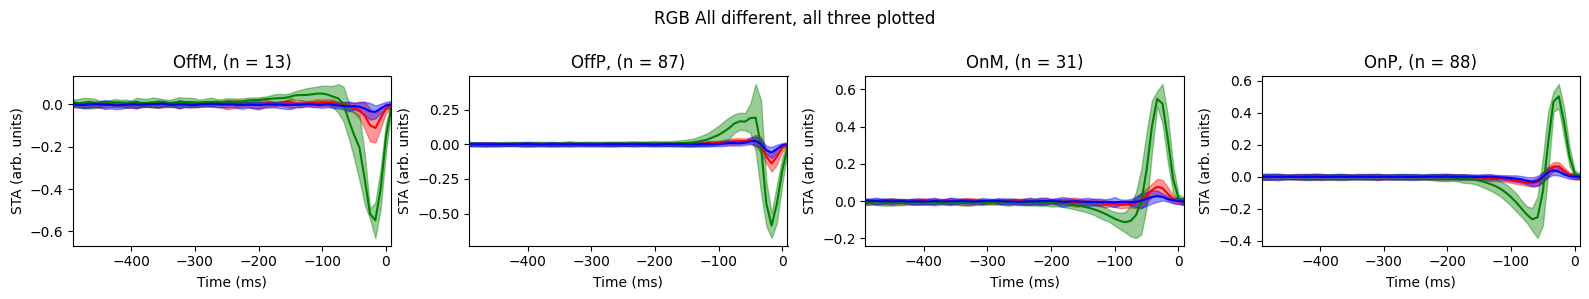

In [ ]:
# Initialize analysis chunk:
analysis_chunk = ra.AnalysisChunk(exp_name, 'chunk2', verbose = False)

# NOTE: Because we are checking the EIs at initialization now, we can find and throw out bad cell_ids that have no electrical image.
# Retinanalysis will throw a warning for each cell that it removes (currently cannot turn this warning off).

# Analysis chunk now has EI dictionary, ISI dictionary, and timecourse dictionary:
EI_dict = analysis_chunk.d_EIs
ISI_dict = analysis_chunk.d_ISIs
timecourse_dict = analysis_chunk.d_timecourses

# Methods like 'plot_timecourses' now use this dictionary instead of the vcd
timecourse_plot = analysis_chunk.plot_timecourses(cell_types = ['OffP', 'OnP', 'OffM', 'OnM'])
fig1 = timecourse_plot[0].get_figure()
fig1.suptitle(f'Red and Green idential, only Green plotted')

# If Red and Green timecourses are identical, only green is plotted. If RGB are all different, all three are plotted:
rgb_analysis_chunk = ra.AnalysisChunk('20251202C', 'chunk2', verbose = False)
rgb_plot = rgb_analysis_chunk.plot_timecourses(cell_types = ['OffP', 'OnP', 'OffM', 'OnM'])
fig2 = rgb_plot[0].get_figure()
fig2.suptitle(f'RGB All different, all three plotted');

In [ ]:
# MEA Pipeline stim_block and response_block have been renamed to stim and resp. Old calls still work but throw deprecation warnings
pipeline = ra.create_mea_pipeline(exp_name, sample_datafile, analysis_chunk_name = 'chunk2',
                                  typing_file = 'dragos_kilosort2.5.classification.txt', 
                                  b_load_fd = True, verbose = False)

print('\n')
# Will throw a warning:
response_block = pipeline.response_block
stim_block = pipeline.stim_block

# Won't throw warnings
response_block = pipeline.resp
stim_block = pipeline.stim


## Stim and Response Groups

There are now two new objects: `MEAStimGroup` and `MEAResponseGroup` that concatenate stim blocks and response blocks from multiple datafiles, respectively, into a single object with most of the same properties.

### General Info
Stim Groups and Response Groups simply take the values in a list of Stim Blocks or list of Response Blocks, and concatenate along the epoch dimension.
- E.g. 9 datafiles of 100 epochs each will produce an `MEAStimGroup` with `df_epochs` dataframe that contains 900 epochs, and an `MEAResponseGroup` with `df_spike_times` dataframe with 900 epochs of spike times for each cell.
- NOTE: Only cell ids that appear in all of the included datafiles will be included in the group. This often means losing between 1 and 6 cells, because they had zero spikes in one of the included datafiles.

They contain most of the same properties as Stim Block and Response Block. Use print() command to see all properties.
Key differences:
- `MEAStimGroup.nearest_noise_chunk` is the chunk that is closest to the most datafiles in the group. If two chunks 'tie' for closest, the earlier chunk is currently chosen by default.
- `object.datafile_name` is `object.datafile_names`
- `object.block_id` is `object.block_ids`
- `frame_sample_rate` is `frame_sample_rates`, BUT if all sample rates are the same, only one value is included.
- both objects contain an `ls_blocks` property that contains the list of stim or response blocks used to build the stim or response group, so you can still access them individually
- in `MEAStimGroup`, the `d_epoch_block_parameters` dictionary will contain the same keys, but the values will be a list of params that is the same length as the number of datafiles if and only if that parameter changes at any point between the datafiles.
    - i.e. If there are six datafiles and all epoch block params stay the same except a param named stixel size, which changes from 150 to 100 halfway through, all `d_epoch_block_params` values will be single values except stixel size, which will: `[150, 150, 150, 100, 100, 100]` 

### Creating Stim and Response Group Objects
To create an `MEAStimGroup` or `MEAResponseGroup` you can either:
1. Manually initialize them using a list of `MEAStimBlock` or `MEAResponseBlock` objects, respectively. 
    - Eg. `ra.MEAStimGroup(ls_blocks: [List of MEAStimBlock objects])`
2. Use dedicated dedicated functions `ra.create_mea_response_group()` and `ra.create_mea_stim_group()` functions, which take an experiment name and a list of datafiles:
    - Eg. `ra.create_mea_stim_group(exp_name = '20251112C', ls_datafile_names: ['data007', 'data008', 'data009'])` 

Option 2 is much easier, but have at it if you want to manually create and concatenate ResponseBlocks and StimBlocks.
- NOTE: StimGroup and ResponseGroup objects require that all datafiles be part of the same sorting chunk and protocol. You cannot concatenate blocks created from datafiles that were not sorted together or used different protocols. 

### Additional Params
Just like `ra.MEAStimBlock()` and `ra.MEAResponseBlock`, you can feed additional params into `create_mea_stim_group` and `create_mea_response_group`.
- For Stim Groups:
    - `ls_params` (default: `None`): feed in a list of params that you want to make sure will appear in the stim group property `df_epochs`
- For Response Groups:
    - `b_load_fd` (default: `False`): Boolean that, when true, will load all frame monitor data into the response group's `frame_data` and `sample_rate` property 
- For both:
    - `verbose` (default: `False`): Unlike StimBlock and ResponseBlock, the `Verbose` parameter is set to False by default for both StimGroup and ResponseGroup, because creating so many Stim Blocks and Response Blocks (plus concatenating them) generates a lot of status messages, but you can always override this and set the param to True if you want to see how things are going.
    - NOTE: Warning messages will print no matter what


In [5]:
# Create Stim Group and Stim Block to compare
stim_block = ra.MEAStimBlock(exp_name, sample_datafile, ls_params = ['fileFolder'], verbose = False)
stim_group = ra.create_mea_stim_group(exp_name, ls_datafiles, ls_params = ['fileFolder'], verbose = False)

# Compare params between StimBlock and StimGroup:
print(stim_block)
print(stim_group)

MEAStimBlock with properties:
  exp_name: 20251112C
  block_id: 3893
  prep_label: Mount1
  datafile_name: data007
  chunk_name: defocus
  protocol_name: edu.washington.riekelab.protocols.PresentMatFiles
  noise_protocol_name: manookinlab.protocols.SpatialNoise
  nearest_noise_chunk: chunk2
  parameter_names of length: 63
  d_epoch_block_params with keys: dict_keys(['amp', 'amp2', 'gapTime', 'preTime', 'stimTime', 'tailTime', 'flashTime', 'randomize', 'fileFolder', 'sampleRate', 'defocusStates', 'imagesPerEpoch', 'onlineAnalysis', 'numberOfAverages', 'interpulseInterval', 'backgroundIntensity'])
  df_epochs for 100 epochs

MEAStimGroup with properties:
  ls_blocks containing 9 MEAStimBlocks
  exp_name: 20251112C
  block_ids: [np.int64(3893), np.int64(3894), np.int64(3895), np.int64(3896), np.int64(3897), np.int64(3898), np.int64(3899), np.int64(3900), np.int64(3901)]
  prep_label: Mount1
  datafile_names: ['data007', 'data008', 'data009', 'data010', 'data011', 'data012', 'data013', 'da

In [6]:
# Create Response Group and Respones Block to compare
response_block = ra.MEAResponseBlock(exp_name, sample_datafile, b_load_fd = True, verbose = False)
response_group = ra.create_mea_response_group(exp_name, ls_datafiles, b_load_fd = True, verbose = False)

# Compare params between ResponseBlock and ResponseGroup:
print(response_block)
print(response_group)

MEAResponseBlock with properties:
  exp_name: 20251112C
  datafile_name: data007
  protocol_name: edu.washington.riekelab.protocols.PresentMatFiles
  ss_version: kilosort2.5
  n_epochs: 100
  cell_ids of length: 568
  df_spike_times with times for 568 cells
  block_id: 3893
  d_EIs dictionary containing EIs for 568 cell IDs
  d_timing with keys: ['exp_name', 'block_id', 'frameTimesMs', 'epochStarts', 'epochEnds', 'n_samples', 'n_epochs', 'pre_time_ms', 'stim_time_ms', 'tail_time_ms', 'stage_frame_rate', 'actual_onset_times_ms', 'actual_offset_times_ms']
  frame_sample_rate: 1000.0
  frame_data shape: (100, 2500)

MEAResponseGroup with properties:
  ls_blocks containg 9 MEAResponseBlocks
  exp_name: 20251112C
  datafile_names: ['data007', 'data008', 'data009', 'data010', 'data011', 'data012', 'data013', 'data014', 'data015']
  protocol_name: edu.washington.riekelab.protocols.PresentMatFiles
  ss_version: kilosort2.5
  n_epochs: 900
  cell_ids of length: 566
  df_spike_times with times f

## DF Epochs and DF Spike Times

The most important concatenation that happens when you create a StimGroup or ResponseGroup happens in the `stim.df_epochs` and `resp.df_spike_times` dataframes:

### MEAStimGroup.df_epochs
- DF Epochs is concatenated along the epoch dimension, so a 100 epoch dataframe per datafile, and 9 datafiles, will produce a Stim Group with a 900 epoch dataframe.
    - A new column named `datafile_epoch_index` has been added that retains the epoch index from each datafile, while the `epoch_index` column now counts up to the total number of epochs.

In [7]:
# Compare stim block df_epochs to stim group df_epochs:
display(stim_block.df_epochs)
display(stim_group.df_epochs)

# Note the new column 'datafile_epoch_index' that only exists in the stim group dataframe

,epoch_index,imageOrder,matFile,fileFolder,randomizedOrder,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,"[-3.0, 0.0, 3.0, -5.0, 5.0]",checkerboard_150_1.mat,DefocusImages_150um,"[2.0, 3.0, 4.0, 1.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271599
1,1,"[-5.0, -3.0, 0.0, 3.0, 5.0]",checkerboard_150_10.mat,DefocusImages_150um,"[1.0, 2.0, 3.0, 4.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271600
2,2,"[3.0, -3.0, 0.0, -5.0, 5.0]",checkerboard_150_100.mat,DefocusImages_150um,"[4.0, 2.0, 3.0, 1.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271601
3,3,"[0.0, -5.0, 3.0, 5.0, -3.0]",checkerboard_150_101.mat,DefocusImages_150um,"[3.0, 1.0, 4.0, 5.0, 2.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271602
4,4,"[-3.0, 5.0, 3.0, -5.0, 0.0]",checkerboard_150_102.mat,DefocusImages_150um,"[2.0, 5.0, 4.0, 1.0, 3.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,"[0.0, 5.0, -3.0, 3.0, -5.0]",checkerboard_150_185.mat,DefocusImages_150um,"[3.0, 5.0, 2.0, 4.0, 1.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271694
96,96,"[5.0, -5.0, 0.0, 3.0, -3.0]",checkerboard_150_186.mat,DefocusImages_150um,"[5.0, 1.0, 3.0, 4.0, 2.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271695
97,97,"[-3.0, 5.0, 0.0, -5.0, 3.0]",checkerboard_150_187.mat,DefocusImages_150um,"[2.0, 5.0, 3.0, 1.0, 4.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271696
98,98,"[0.0, -3.0, 3.0, -5.0, 5.0]",checkerboard_150_188.mat,DefocusImages_150um,"[3.0, 2.0, 4.0, 1.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271697


,epoch_index,datafile_epoch_index,imageOrder,matFile,fileFolder,randomizedOrder,exp_name,datafile_name,group_label,protocol_name,...,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,0,"[-3.0, 0.0, 3.0, -5.0, 5.0]",checkerboard_150_1.mat,DefocusImages_150um,"[2.0, 3.0, 4.0, 1.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271599
1,1,1,"[-5.0, -3.0, 0.0, 3.0, 5.0]",checkerboard_150_10.mat,DefocusImages_150um,"[1.0, 2.0, 3.0, 4.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271600
2,2,2,"[3.0, -3.0, 0.0, -5.0, 5.0]",checkerboard_150_100.mat,DefocusImages_150um,"[4.0, 2.0, 3.0, 1.0, 5.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271601
3,3,3,"[0.0, -5.0, 3.0, 5.0, -3.0]",checkerboard_150_101.mat,DefocusImages_150um,"[3.0, 1.0, 4.0, 5.0, 2.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271602
4,4,4,"[-3.0, 5.0, 3.0, -5.0, 0.0]",checkerboard_150_102.mat,DefocusImages_150um,"[2.0, 5.0, 4.0, 1.0, 3.0]",20251112C,data007,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data007,250.0,2000.0,250.0,160,2659,3893,68,271603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,95,"[-5.0, 5.0, 3.0, 0.0, -3.0]",checkerboard_50_185.mat,DefocusImages_50um,"[1.0, 5.0, 4.0, 3.0, 2.0]",20251112C,data015,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data015,250.0,2000.0,250.0,160,2659,3901,68,272494
896,896,96,"[-5.0, 3.0, -3.0, 0.0, 5.0]",checkerboard_50_186.mat,DefocusImages_50um,"[1.0, 4.0, 2.0, 3.0, 5.0]",20251112C,data015,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data015,250.0,2000.0,250.0,160,2659,3901,68,272495
897,897,97,"[0.0, 3.0, 5.0, -3.0, -5.0]",checkerboard_50_187.mat,DefocusImages_50um,"[3.0, 4.0, 5.0, 2.0, 1.0]",20251112C,data015,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data015,250.0,2000.0,250.0,160,2659,3901,68,272496
898,898,98,"[-5.0, 0.0, -3.0, 3.0, 5.0]",checkerboard_50_188.mat,DefocusImages_50um,"[1.0, 3.0, 2.0, 4.0, 5.0]",20251112C,data015,defocus,edu.washington.riekelab.protocols.PresentMatFiles,...,"{'NDF': 0.5, 'amp': 'Amp1', 'amp2': '(None)', ...",20251112C/data015,250.0,2000.0,250.0,160,2659,3901,68,272497


### MEAResponseGroup.df_spike_times
- DF Spike Times will contain only those cell ids that appear in all of the datafiles used to create the Group (usually 1-6 fewer cells than the max number of cells in any individual datafile).
    - The major change is in the `spike_times` column, where each cell_ids list of spike time arrays is concatenated along the epoch dimension.
    - e.g. If 9 datafiles of 100 epochs each are combined into a group, df_spike_times for each response block will have a list of 100 spike time arrays for each cell (one for each epoch), while df_spike_times for the response group will have a list of 900 spike time arrays. 

In [8]:
# Compare response block df_spike_times to response group df_spike_times
display(response_block.df_spike_times)
display(response_group.df_spike_times)

# Note the length of each spike time array:
display(f"{len(response_block.df_spike_times.loc[0, 'spike_times'])} epochs in response block spike times")
display(f"{len(response_group.df_spike_times.loc[0, 'spike_times'])} epochs in response group spike times")

,cell_id,spike_times
0,1,"[[86.0, 140.4, 206.9, 240.85000000000002, 264...."
1,3,"[[224.35, 1086.6499999999999, 1096.95, 1103.9,..."
2,4,"[[187.54999999999998, 241.85000000000002, 245...."
3,5,"[[733.05, 750.3499999999999, 760.35, 1486.3999..."
4,6,"[[5.15, 42.95, 93.7, 149.95, 206.0, 238.1, 428..."
...,...,...
563,883,"[[1442.3999999999999, 1498.75, 1779.75, 1938.5..."
564,888,"[[1809.9, 1959.3, 2098.0, 2424.7000000000003, ..."
565,889,"[[], [], [1620.6499999999999], [], [], [], [21..."
566,890,"[[64.0, 261.5, 441.8, 490.55, 594.85, 609.5500..."


,cell_id,spike_times
0,1,"[[86.0, 140.4, 206.9, 240.85000000000002, 264...."
1,3,"[[224.35, 1086.6499999999999, 1096.95, 1103.9,..."
2,4,"[[187.54999999999998, 241.85000000000002, 245...."
3,5,"[[733.05, 750.3499999999999, 760.35, 1486.3999..."
4,6,"[[5.15, 42.95, 93.7, 149.95, 206.0, 238.1, 428..."
...,...,...
561,888,"[[1809.9, 1959.3, 2098.0, 2424.7000000000003, ..."
562,889,"[[], [], [1620.6499999999999], [], [], [], [21..."
563,890,"[[64.0, 261.5, 441.8, 490.55, 594.85, 609.5500..."
564,891,"[[920.15, 1229.0, 1923.8], [], [995.05], [1157..."


'100 epochs in response block spike times'

'900 epochs in response group spike times'

## Other Miscellaneous Updates

The QC pipeline and the Cluster Matching pipeline have both been updated to be able to take Stim and Response Groups, not just Stim and Response Blocks

The QC pipeline has been updated to pull all relevant spike counts and refractory violations from Response Groups in addition to Response Blocks.
- Total spike counts are now more accurate. Previously we used the built in VCD method for pulling spike counts, but this also counted spikes that happened between epochs. Now we pull spike counts only from within epochs. 

The `cluster_match()`, `ei_corr()` and `classification_transfer()` functions in `vision_utils` have all been updated to accept Stim and Response Groups. 

The `get_timecourses()` and `plot_timecourses()` methods have been updated to pull this data from the d_timecourses dictionary instead of the VCD.

The `get_spike_xarr()` and `get_spike_dict()` methods have been updated to take Stim and Response Groups, not just Stim and Response Blocks